
# Versuch 1 - Entfernungsmesser mit nichtlinearer Kennlinie von 10cm bis 70cm, jeder Testvorgang jeweils im Abstand von 3cm

## Teilaufgabe 1

### Zuerst werden alle Werte gemessen und die gemessenen Mittelwerte werden protokolliert.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Vorüberlegung: Bei 10cm starten, bis 70, Abstände ohne Fehlerrechnung (ohne Blatt)
means = [1.426, 1.243, 1.107, 1.017, 0.9199, 0.8561, 0.8003, 0.7459, 0.7058, 0.6653, 0.6287,
        0.6107, 0.5698, 0.5531, 0.5268, 0.4945, 0.4732, 0.4744, 0.4567, 0.4353, 0.4189] # in V
print(means)

[1.426, 1.243, 1.107, 1.017, 0.9199, 0.8561, 0.8003, 0.7459, 0.7058, 0.6653, 0.6287, 0.6107, 0.5698, 0.5531, 0.5268, 0.4945, 0.4732, 0.4744, 0.4567, 0.4353, 0.4189]


### Nun werden alle Werte, gespeichert in den dazu korrespondierenden .csv-Dateien, eingelesen und die berechneten Mittelwerte und Standardabweichungen ausgegeben

In [3]:
means_calc = []
for i in range(10, 71, 3):
    df = pd.read_csv(f"./Versuch1-{i}.csv", sep=";", decimal=",", skiprows=range(1, 1001)) # die ersten 1000 Werte werden übersprungen
    mean = np.mean(df["Kanal A"])
    means_calc.append(mean)
    print(f"\u001b[3;35mMean for {i}cm: {mean}\u001b[0m")
    std = np.std(df["Kanal A"], ddof=1)
    print(f"\u001b[1;34mStd for {i}cm: {std}\u001b[0m\n")

Mean for 10cm: 1.426374212797604
Std for 10cm: 0.02420643234823116

Mean for 13cm: 1.242994392786465
Std for 13cm: 0.02445307210577628

Mean for 16cm: 1.1067726333219836
Std for 16cm: 0.023887853071684728

Mean for 19cm: 1.0170896194122527
Std for 19cm: 0.022422589270204896

Mean for 22cm: 0.9198457115786042
Std for 22cm: 0.023539303991733915

Mean for 25cm: 0.8561134928066412
Std for 25cm: 0.022490497903436883

Mean for 28cm: 0.8002881626306219
Std for 28cm: 0.019162417148230606

Mean for 31cm: 0.7458601500799705
Std for 31cm: 0.018672695750560703

Mean for 34cm: 0.705682124887873
Std for 34cm: 0.017480168698563083

Mean for 37cm: 0.6651259848701134
Std for 37cm: 0.020729208187213393

Mean for 40cm: 0.6286134909332703
Std for 40cm: 0.024031802334018464

Mean for 43cm: 0.6107348459273856
Std for 43cm: 0.018544449688351672

Mean for 46cm: 0.5697958044055276
Std for 46cm: 0.020499588816344054

Mean for 49cm: 0.5531183827262506
Std for 49cm: 0.02118105200160036

Mean for 52cm: 0.526868793

## Teilaufgabe 2

### Um die Kennlinie, und die damit darzustellende Übertragungsfunktion, mittels linearer Regression, graphisch darstellen zu können, muss bei einem nichtlinearen Sharp-Sensor erst jeder signifikante Teil (Ein-, Aus-; Abstand, Spannung) logarithmiert werden und in Zusammenhang gebracht werden, sodass gilt:


#### $$y' = \ln y = \ln{(x^a)} = a \cdot \ln x = a \cdot \ln{(e^{x'})} = a \cdot x'$$
### und es dadurch linear wird.



### $$Bei\ x \in \{10 + 3k \mid k \in \mathbb{N}_0, 10 + 3k \leq 70 \} \land y := gemessene\ Spannungen:$$ 

#### Zuerst Numpy-Floats zur besseren Darstellung in Python-native Floats konvertieren.

In [4]:
means_calc = np.float64(means_calc)
print(means_calc)

[1.42637421 1.24299439 1.10677263 1.01708962 0.91984571 0.85611349
 0.80028816 0.74586015 0.70568212 0.66512598 0.62861349 0.61073485
 0.5697958  0.55311838 0.52686879 0.49439823 0.47321163 0.4743423
 0.45662413 0.43530759 0.41893736]


#### Nun die unterschiedlichen gemessenen und kalkulierten Messwerte graphisch darstellen, um deren Unterschiede graphisch darzustellen.

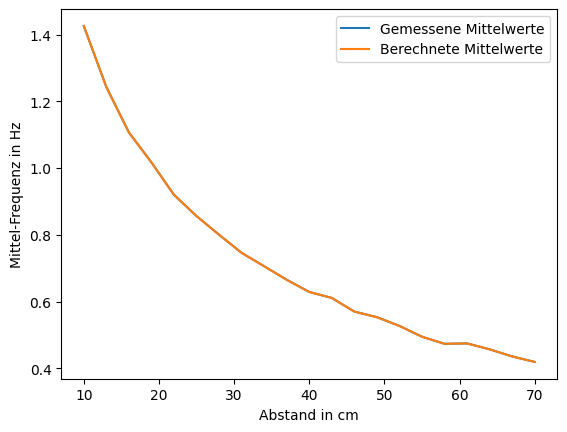

In [11]:
xs = [i for i in range(10, 71, 3)]

plt.plot(xs, means, label="Gemessene Mittelwerte")
plt.plot(xs, means_calc, label="Berechnete Mittelwerte")
plt.legend()
plt.xlabel("Abstand in cm")
plt.ylabel("Mittel-Frequenz in Hz")
plt.show()

### So sehen wir, dass die gemessenen sowie die berechneten Werte identisch sind, damit können wir für das weitere Verfahren die berechneten Werte übernommen werden.

## Nun werden alle Eingangs- (Abstand) und Ausgangs- (Hertz) Werte logarithmiert, um daraus eine lineare Regression bilden zu können.

ln(Hz): $[ 0.35513571  0.2175233   0.10144824  0.01694523 -0.08354933 -0.15535233
 -0.22278341 -0.29321716 -0.34859039 -0.40777881 -0.46423869 -0.49309238
 -0.56247722 -0.59218323 -0.64080373 -0.70441396 -0.74821257 -0.74582606
 -0.78389469 -0.8317024  -0.87003388]
ln(cm): $[2.30258509 2.56494936 2.77258872 2.94443898 3.09104245 3.21887582
 3.33220451 3.4339872  3.52636052 3.61091791 3.68887945 3.76120012
 3.8286414  3.8918203  3.95124372 4.00733319 4.06044301 4.11087386
 4.15888308 4.20469262 4.24849524]


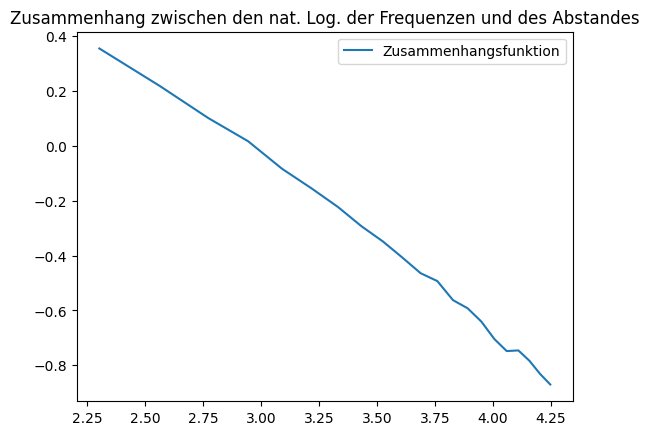

In [12]:
lnx = np.log(means_calc)
lny = np.log(xs)
print(f"ln(Hz): ${lnx}\nln(cm): ${lny}")
plt.title("Zusammenhang zwischen den nat. Log. der Frequenzen und des Abstandes")
plt.plot(lny, lnx, label="Zusammenhangsfunktion")
plt.legend()
plt.show()

## Jetzt werden noch die fehlenden Parameter a und b, welche für
$$ y' = a \cdot x' + b $$
benötigt werden, mittels linearer Regression ermittelt.

Steigung a: $-1.5610053594279736
y-Achsenabschnitt b: 2.943861082193612


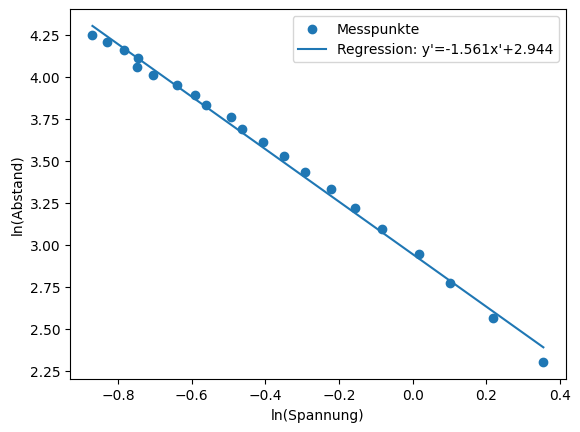

[0.52179182 0.34644243 0.25053296 0.19158495 0.15239602 0.12482765
 0.10458784 0.08922345 0.07724241 0.06769106 0.05993471 0.05353645
 0.04818687 0.04366138 0.03979351 0.03645752 0.03355692 0.03101653
 0.02877703 0.02679107 0.02502043]


In [13]:
a, b = np.polyfit(lnx, lny, 1)

print(f"Steigung a: ${a}\ny-Achsenabschnitt b: {b}")

plt.scatter(lnx, lny, label="Messpunkte")
plt.plot(lnx, a * lnx + b, label=f"Regression: y'={a:.3f}x'+{b:.3f}")
plt.legend()
plt.xlabel("ln(Spannung)")
plt.ylabel("ln(Abstand)")
plt.show()

print(np.exp(a*lny+b))

## Teilaufgabe 3
### a.

In [14]:
df = pd.read_csv(f"./Versuch1-dina4-l.csv", sep=";", decimal=",", skiprows=range(1, 1001))
mean = np.mean(df["Kanal A"])
std = np.std(df["Kanal A"], ddof=1)
print(f"Mittelwerte: {mean}")
print(f"Empirische Standardabweichung: {std}")

Mittelwerte: 0.7625900582198403
Empirische Standardabweichung: 0.022294664436437475


### Die Anzahl an Messungen beträgt ca. 30, somit wird für eine Sicherheit von 68% eine Korrektur von 1.02, für eine Sicherheit von 95% eine Korrektur von 2.05 angenommen.

In [15]:
conf68 = (mean - 1.02*std, mean + 1.02*std) # confide - Vertrauen
conf95 = (mean - 2.05*std, mean + 2.05*std)
print(f"Vertrauen 68%: {conf68}\nVertrauen 95%: {conf95}")

Vertrauen 68%: (np.float64(0.739849500494674), np.float64(0.7853306159450065))
Vertrauen 95%: (np.float64(0.7168859961251435), np.float64(0.8082941203145371))


### Gaußsche Fehlerfortpflanzung. 

In [19]:
y = np.exp(b) * mean**a
s_y = np.exp(b) * abs(a) * mean**(a-1) * std

print(f"Abstand; {y} cm +- {s_y} cm für 68%")

df = pd.read_csv(f"./Versuch1-dina4-w.csv", sep=";", decimal=",", skiprows=range(1, 1001))
mean = np.mean(df["Kanal A"])
std = np.std(df["Kanal A"], ddof=1)
print(f"Mittelwerte: {mean}")
print(f"Empirische Standardabweichung: {std}")
l, w = 29.7, 21
s_w = np.exp(b) * abs(a) * mean**(a-1) * std
a = l * w
s_a = a * np.sqrt((s_y/l)**2 + (s_w/w)**2)

print(f"Fläche: {a:.2f} +- {s_a:} cm²")

Abstand; 3.946303435179902e-11 cm +- 6.185975493783958e-10 cm für 68%
Mittelwerte: 0.957787888120534
Empirische Standardabweichung: 0.024071952423887526
Fläche: 623.70 +- 2.250105538715467e-08 cm²
